In [1]:
# importing required modules
import matplotlib.pyplot as plt
from vasttools.query import Query
import pandas as pd

from vasttools.moc import VASTMOCS
from astropy import units as u

import numpy as np

from astropy.coordinates import SkyCoord

import scipy.stats as stats

In [2]:
# setting plot preferences
%matplotlib inline

In [3]:
data_path = 'final_products/test_cand_controls.csv'
row = 6 #should be zero-indexed
dec_column = 'dec_deg_cont'
ra_column = 'ra_deg_cont'

In [4]:
data = pd.read_csv(data_path)

In [132]:
stuff = data[data.iloc[:,0]=='J1809-1943']

In [133]:
droppables = []
for i in np.arange(stuff.shape[0]):
    if stuff.index[i] in droppables:
        continue
    print(i)
    value = stuff.iloc[i]['distance']
    for j in (np.arange(stuff.shape[0] - (i + 1)) + (i+1)):
        if (stuff.iloc[j]['distance'] < (value+15)):
            droppables.append(stuff.index[j])

0
6
12
18
20
26
29
39
41
50
51
57
63
69
73
76
82
88
99
105
109
114
115
121
129
130
132
137
139
140
146
152
161
167
179
185
191
197
199
205
209
215
218
224
239
250
256
262
272
279
287
289
301
307
319
321


In [138]:
stuff['distance'].iloc[18]

887.2105246344272

In [57]:
#query_coord = controls_df.sort_values('chi_squared', ascending=False).iloc[0]['skycoord']
query_coord = SkyCoord(str(data.iloc[row][ra_column]) + " " + str(data.iloc[row][dec_column]), unit='deg')
query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False, post_processed_data=False)
query.find_sources()

Removing source_171256.1-341338.7: Epoch 5x due to missing files
Removing source_171256.1-341338.7: Epoch 6x due to missing files
Removing source_171256.1-341338.7: Epoch 8 due to missing files


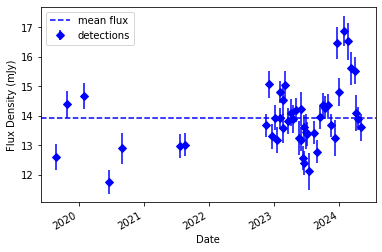

In [58]:
psr_meas = query.results[0].measurements[query.results[0].measurements['freq']==887.5]
    
    
#basically makes a lightcurve, largely copied from 'plot_lightcurves' source code
sigma_thresh=5
figsize = (8, 4)
min_points = 2
min_detections = 0
mjd= False
# TODO: Is this a pd.Timestamp or a datetime?
start_date = None
grid= False
yaxis_start = "0"
peak_flux= True
save = False
outfile = None
use_forced_for_limits = False
use_forced_for_all = False
hide_legend = False
plot_dpi = 150

fig, ax = plt.subplots()
    
measurements = psr_meas
    
upper_lim_mask = measurements.detection == False
upper_lims = measurements[upper_lim_mask]
    
plot_dates = measurements['dateobs']
    
value_col = err_value_col = 'rms_image'
uplims = True
flux_col = "flux_peak"

marker = "D"
markerfacecolor = 'blue'

if upper_lim_mask.any():
        upperlim_points = ax.errorbar(
            plot_dates[upper_lim_mask],
            sigma_thresh *
            upper_lims[value_col],
            yerr=upper_lims[err_value_col],
            uplims=uplims,
            lolims=False,
            marker=marker,
            c='blue',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            #label=label
        )
    
detections = measurements[~upper_lim_mask]
marker = 'D'
markerfacecolor = 'blue'
        
if (~upper_lim_mask).any():
        detection_points = ax.errorbar(
            plot_dates[~upper_lim_mask],
            detections[flux_col],
            yerr=detections[err_value_col],
            marker=marker,
            c='blue',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            label='detections'
        )
        
    
        
ax.axhline(psr_meas['flux_peak'].mean(), linestyle='dashed', label='mean flux', color='blue')
    
    
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Flux Density (mJy)')
ax.legend()